# Raw Data

In [1]:
# load a excel file and print the first 5 rows
import pandas as pd

# file_path = r"c:\Users\Rafael\Downloads\Perguntas - Benchmark.xlsx"
# file_path = "/media/rafael/D00CBD870CBD68DC/Users/Rafael/Downloads/Perguntas - Benchmark.xlsx"
file_path = "/home/rafael/P3B3/Perguntas - Benchmark.xlsx"

# read the sheet named P3B3+
df = pd.read_excel(file_path, sheet_name='P3B3+')
df

FileNotFoundError: [Errno 2] No such file or directory: '/home/rafael/P3B3/Perguntas - Benchmark.xlsx'

In [5]:
# the column named prompt has a list of strings that form a dialogue lets extract them into a list
dialogues = df['prompt'].tolist()

dialogues[:2]

['[\n"Que eletrodomésticos é que devo aproveitar para comprar na black friday?",\n"Qual é o eletrodoméstico mais caro numa cozinha?",\n"Quais são os melhores eletrodomésticos para conservar comida a uma temperatura baixa?"\n]',
 '[\n"O meu carro está na oficina. Que transportes posso usar como alternativa?",\n"Há uma diferença de tempo muito grande entre ir num transporte público e ir de carro?",\n"É mais fácil ir para o centro de uma cidade de carro ou de transportes?"\n]']

In [6]:
import json

# now lets turn each dialogue into a list of messages we can load them with json
all_messages = []
for dialogue in dialogues:
    messages = json.loads(dialogue)
    all_messages.append(messages)

all_messages[0:2]

[['Que eletrodomésticos é que devo aproveitar para comprar na black friday?',
  'Qual é o eletrodoméstico mais caro numa cozinha?',
  'Quais são os melhores eletrodomésticos para conservar comida a uma temperatura baixa?'],
 ['O meu carro está na oficina. Que transportes posso usar como alternativa?',
  'Há uma diferença de tempo muito grande entre ir num transporte público e ir de carro?',
  'É mais fácil ir para o centro de uma cidade de carro ou de transportes?']]

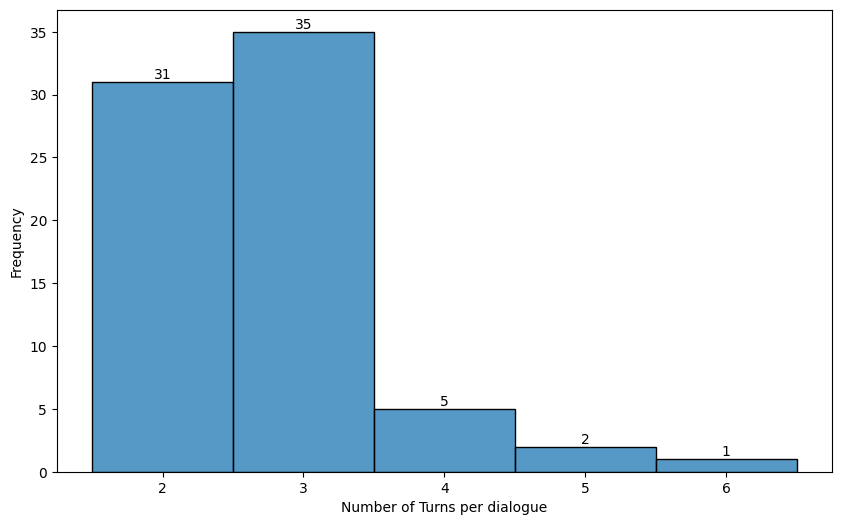

Distribution of Number of Messages per Dialogue:
2    31
3    35
4     5
5     2
6     1
dtype: int64


count    74.000000
mean      2.743243
std       0.811912
min       2.000000
25%       2.000000
50%       3.000000
75%       3.000000
max       6.000000
dtype: float64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import numpy as np

num_messages = [len(messages) for messages in all_messages]

# Create the plot
plt.figure(figsize=(10, 6))

# Use discrete=True to center bars on integer values
sns.histplot(num_messages, discrete=True)

# Force the x-axis to only show integer ticks
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel('Number of Turns per dialogue')
plt.ylabel('Frequency')
# plt.title('Number of Turns per Dialogue')

# put the number on top of each bar
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{int(height)}',
                       (p.get_x() + p.get_width() / 2, height),
                       ha='center', va='bottom')


# save image as pdf
plt.savefig('messages_per_dialogue_histogram.pdf')

plt.show()

# print the distribution of number of messages
number_of_messages_distribution = pd.Series(num_messages).value_counts().sort_index()
print("Distribution of Number of Messages per Dialogue:")
print(number_of_messages_distribution)

# use pandas to get some statistics
stats = pd.Series(num_messages).describe()
stats

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator

# Standard scientific context using regular fonts
#sns.set_context("paper", font_scale=1.4)
#sns.set_style("white") 

fig, ax = plt.subplots(figsize=(8, 5))

# Plotting the data
sns.histplot(num_messages, 
             discrete=True, 
             color="#4C72B0", 
             edgecolor='black', 
             linewidth=1.2,
             shrink=0.7)

# Adjust Y-limit to provide 15% headrom for labels
counts = pd.Series(num_messages).value_counts()
ax.set_ylim(0, counts.max() * 1.15)

# Keep the full frame (the box)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

# Labels
ax.set_xlabel('Number of Turns per Dialogue', labelpad=10)
ax.set_ylabel('Frequency', labelpad=10)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Remove ticks from top and right, but keep them on bottom and left
ax.tick_params(top=False, right=False, direction='out')

# Add the count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', 
                    fontsize=12, 
                    xytext=(0, 5),
                    textcoords='offset points')
        
# increase font size of ticks
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig('clean_scientific_histogram.pdf', dpi=300)
plt.show()

In [ ]:
# total number of dialogues
total_dialogues = len(all_messages)
print(f'Total number of dialogues: {total_dialogues}')

# total number of messages
total_messages = sum(num_messages)
print(f'Total number of messages: {total_messages}')

In [ ]:
# and now calculate the size of prompts in terms of number of words and characters
num_words = [sum(len(message.split()) for message in messages) for messages in all_messages]

# get statistics for words and characters
word_stats = pd.Series(num_words).describe()
print("Word count statistics for dialogues:")
print(word_stats)

In [ ]:
num_characters = [sum(len(message) for message in messages) for messages in all_messages]
char_stats = pd.Series(num_characters).describe()
print("Character count statistics for dialogues:")
print(char_stats)

# Scores

## Encoders

In [ ]:
# now lets open all csv files in a folder and load them into a single dataframe

import os
import pandas as pd

# folder_path = r"c:\Users\Rafael\Downloads\p3b3"
# folder_path = "/media/rafael/D00CBD870CBD68DC/Users/Rafael/Downloads/p3b3"
folder_path = "/home/rafael/P3B3/p3b3"

all_results = []
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder_path, filename)
        df_results = pd.read_csv(file_path)
        all_results.append(df_results)

results_df = pd.concat(all_results, ignore_index=True)

# add one to the turn_nr column to make it 1 indexed
results_df['turn_nr'] = results_df['turn_nr'] + 1

print("Number of files loaded:", len(all_results))
print(f'Total number of results: {len(results_df)}')
print("Number of unique models:", results_df['model_name'].nunique())
results_df


Number of files loaded: 28
Total number of results: 5684
Number of unique models: 14


,prompt_id,model_name,raw_output,turn_nr,prompt_type,user,assistant,PtVId,PtVId_score,PeroVaz_PT-BR_Classifier,PeroVaz_PT-BR_Classifier_score
0,p0t,Qwen 2.5-7B,"<|im_start|>system\nYou are Qwen, created by A...",1,pt-pt,Que eletrodomésticos é que devo aproveitar par...,"Na Black Friday, é uma boa oportunidade para c...","{'PT-PT': np.float64(0.5514148473739624), 'PT-...",0.551415,"{'BR': np.float64(0.4817200005054474), 'PT': n...",0.518280
1,p0t,Qwen 2.5-7B,"<|im_start|>system\nYou are Qwen, created by A...",2,pt-pt,Qual é o eletrodoméstico mais caro numa cozinha?,O eletrodoméstico mais caro numa cozinha geral...,"{'PT-BR': np.float64(0.5595886707305908), 'PT-...",0.440411,"{'BR': np.float64(0.665400505065918), 'PT': np...",0.334599
2,p0t,Qwen 2.5-7B,"<|im_start|>system\nYou are Qwen, created by A...",3,pt-pt,Quais são os melhores eletrodomésticos para co...,Para conservar a comida a uma temperatura baix...,"{'PT-BR': np.float64(0.939188539981842), 'PT-P...",0.060811,"{'PT': np.float64(0.6583450138568878), 'BR': n...",0.658345
3,p1t,Qwen 2.5-7B,"<|im_start|>system\nYou are Qwen, created by A...",1,pt-pt,O meu carro está na oficina. Que transportes p...,"Se o seu carro estiver na oficina, existem vár...","{'PT-PT': np.float64(0.9997368454933167), 'PT-...",0.999737,"{'PT': np.float64(0.8923379182815552), 'BR': n...",0.892338
4,p1t,Qwen 2.5-7B,"<|im_start|>system\nYou are Qwen, created by A...",2,pt-pt,Há uma diferença de tempo muito grande entre i...,"Sim, geralmente há uma diferença significativa...","{'PT-PT': np.float64(0.4763065977022052), 'PT-...",0.476307,"{'BR': np.float64(0.689000815153122), 'PT': np...",0.310999
...,...,...,...,...,...,...,...,...,...,...,...
5679,p71,Mistral-7B,<s>[INST] Estou a fazer uma viagem de carro. E...,3,normal,"Se o meu carro tiver pouco combustível, onde p...","Se o seu carro tiver pouco combustível, você ...","{'PT-BR': np.float64(0.9692258238792419), 'PT-...",0.030774,"{'BR': np.float64(0.5792714953422546), 'PT': n...",0.420728
5680,p72,Mistral-7B,<s>[INST] Queria abrir uma loja de artigos de ...,1,normal,Queria abrir uma loja de artigos de roupa usad...,"A loja que você descreveu, que vende roupas u...","{'PT-BR': np.float64(0.9793360829353333), 'PT-...",0.020664,"{'BR': np.float64(0.6793875098228455), 'PT': n...",0.320612
5681,p72,Mistral-7B,<s>[INST] Queria abrir uma loja de artigos de ...,2,normal,A frente da loja é feita de vidro. O que é que...,Para fazer a frente da sua loja de roupas usa...,"{'PT-BR': np.float64(0.5683000385761261), 'PT-...",0.431700,"{'BR': np.float64(0.8025913536548615), 'PT': n...",0.197409
5682,p73,Mistral-7B,"<s>[INST] Qual o nome da erva aromática usada,...",1,normal,"Qual o nome da erva aromática usada, na sua fo...","A erva aromática usada em pizzas, na sua form...","{'PT-BR': np.float64(0.8264857530593872), 'PT-...",0.173514,"{'PT': np.float64(0.7291197180747986), 'BR': n...",0.729120


## Gemini

In [ ]:
# /user/home/im.paulo/PTPT_Eval_Exams/pt_pt_conversation_full_data.csv

# gemini_df has columns: model_name	conversation_id	turn_number	context	response	score	reasoning	used_pt_pt_prompt

# file_path = "/media/rafael/D00CBD870CBD68DC/Users/Rafael/Downloads/pt_pt_conversation_full_data.csv"
file_path = "/home/rafael/P3B3/pt_pt_conversation_full_data.csv"
df_gemini = pd.read_csv(file_path)
df_gemini

,model_name,conversation_id,turn_number,context,response,score,reasoning,used_pt_pt_prompt
0,allenai_olmo-2-1124-7b-instruct,p0,1,User: Que eletrodomésticos é que devo aproveit...,"A Black Friday, tradicionalmente o dia após o ...",0,A análise detalhada do texto revela um enviesa...,0
1,allenai_olmo-2-1124-7b-instruct,p0,2,User: Que eletrodomésticos é que devo aproveit...,O eletrodoméstico mais caro em uma cozinha ger...,1,A análise do texto revela uma fortíssima incli...,0
2,allenai_olmo-2-1124-7b-instruct,p0,3,User: Que eletrodomésticos é que devo aproveit...,Para conservar alimentos a uma temperatura bai...,1,A análise do texto revela uma forte inclinação...,0
3,allenai_olmo-2-1124-7b-instruct,p0t,1,User: Que eletrodomésticos é que devo aproveit...,"Na Black Friday, que é um dia de grande descon...",2,A resposta apresenta uma mistura clara de cara...,1
4,allenai_olmo-2-1124-7b-instruct,p0t,2,User: Que eletrodomésticos é que devo aproveit...,O eletrodoméstico mais caro em uma cozinha ger...,1,A resposta apresenta um enviesamento muito for...,1
...,...,...,...,...,...,...,...,...
6897,utter-project_eurollm-9b-instruct,p9,2,User: Eu nunca apanhei um voo na minha vida e ...,"Não, você não pode estar sem o cinto de segura...",0,A análise do texto revela um enviesamento tota...,0
6898,utter-project_eurollm-9b-instruct,p9,3,User: Eu nunca apanhei um voo na minha vida e ...,"Durante um voo, você pode pedir ajuda ou solic...",0,A análise detalhada do texto revela uma adesão...,0
6899,utter-project_eurollm-9b-instruct,p9t,1,User: Eu nunca apanhei um voo na minha vida e ...,"Claro, vou explicar-lhe os momentos mais marca...",9,A resposta analisada apresenta uma forte incli...,1
6900,utter-project_eurollm-9b-instruct,p9t,2,User: Eu nunca apanhei um voo na minha vida e ...,"Sim, pode estar sem o cinto de segurança em to...",5,A análise da resposta revela uma mistura clara...,1


In [ ]:
# now we combine df_gemini with results_df

# first we need to rename some columns in df_gemini to match results_df
df_gemini_renamed = df_gemini.rename(columns={
    'conversation_id': 'prompt_id',
    'turn_number': 'turn_nr',
    'score': 'Gemini_score',
    'used_pt_pt_prompt': 'prompt_type'
})

# use same nomenclature for used_pt_pt_prompt which is normal or pt-pt
df_gemini_renamed['prompt_type'] = df_gemini_renamed['prompt_type'].apply(lambda x: 'pt-pt' if x else 'normal')

# remove the final t from prompt_id to match results_df
# df_gemini_renamed['prompt_id'] = df_gemini_renamed['prompt_id'].str.rstrip('t')


# put Gemini_score in 0-1 scale currently is 0-10
df_gemini_renamed['Gemini_score'] = df_gemini_renamed['Gemini_score'] / 10

print("Number of unique models in gemini data:", df_gemini_renamed['model_name'].nunique())

df_gemini_renamed

In [ ]:
print("Model name counts:")
print(results_df["model_name"].unique().tolist())

print("===============================")

# same for gemini
print("Gemini model name counts:")
print(df_gemini_renamed["model_name"].unique().tolist())

In [ ]:
# ['allenai_olmo-2-1124-7b-instruct', 'bsc-lt_salamandra-7b-instruct', 'google_gemma-2-2b-it', 'google_gemma-2-9b-it', 'gpfs_scratch_epor32_amsimplicio_rlvr_outputs_50-4k-dpo-stratified-random-carminho-custom-extra4-safety-beta-0-1_checkpoint-2299', 'gpfs_scratch_epor32_amsimplicio_rlvr_outputs_50-4k-dpo-stratified-random-carminho-custom-extra4-safety-pluspt_checkpoint-3696', 'gpfs_scratch_epor32_amsimplicio_rlvr_outputs_50-new4k-dpo-pt200k-safety_checkpoint-3089-merged', 'gpfs_scratch_epor32_gvmartins_inst-tuning_outputs_50-carminho-big-4k_checkpoint-14399', 'gpfs_scratch_epor32_hub_gemma-3-12b-it', 'gpfs_scratch_epor32_hub_qwen3-8b', 'meta-llama_llama-3.1-8b-instruct', 'mistralai_ministral-8b-instruct-2410', 'mistralai_mistral-7b-instruct-v0.3', 'portulan_gervasio-8b-portuguese-ptpt-decoder', 'qwen_qwen2.5-7b-instruct', 'swiss-ai_apertus-8b-instruct-2509', 'utter-project_eurollm-9b-instruct']


# pretify the the names of the models in the model_name column
pretty_names = {
    "OLMo 2-7B": "OLMo 2-7B",
    "Salamandra-7B": "Salamandra-7B",
    "EuroLLM-9B-Instruct": "EuroLLM-9B",
    "Apertus-8B-Instruct-2509": "Apertus-8B",
    "LLaMA 3.1-Instruct-8B": "LLaMA 3.1-8B",
    "LLaMA-3.1-Gervasio-8B": "LLaMA 3.1 Gervasio-8B",
    "Qwen 2.5-7B": "Qwen 2.5-7B",
    "Qwen3-8B": "Qwen 3-8B",
    "gemma-2-9b-it": "Gemma 2-9B",
    "Gemma-3-12B": "Gemma 3-12B",
    "Mistral-7B": "Mistral-7B",
    "Ministral-8B": "Ministral-8B",
    "50-new4k-dpo-pt200k_safety/checkpoint-3089_merged": "AMALIA-9B DPO OLD",
    "50-4k_dpo_stratified_random_carminho_custom_extra4_safety_pluspt/checkpoint-3696": "AMALIA-9B DPO",
    # gemini version
    "allenai_olmo-2-1124-7b-instruct": "OLMo 2-7B",
    "bsc-lt_salamandra-7b-instruct": "Salamandra-7B",
    "utter-project_eurollm-9b-instruct": "EuroLLM-9B",
    "meta-llama_llama-3.1-8b-instruct": "LLaMA 3.1-8B",
    "portulan_gervasio-8b-portuguese-ptpt-decoder": "LLaMA 3.1 Gervasio-8B",
    "qwen_qwen2.5-7b-instruct": "Qwen 2.5-7B",
    "google_gemma-2-9b-it": "Gemma 2-9B",
    "gpfs_scratch_epor32_hub_gemma-3-12b-it": "Gemma 3-12B",
    "mistralai_mistral-7b-instruct-v0.3": "Mistral-7B",
    "mistralai_ministral-8b-instruct-2410": "Ministral-8B",
    "gpfs_scratch_epor32_amsimplicio_rlvr_outputs_50-new4k-dpo-pt200k-safety_checkpoint-3089-merged": "AMALIA-9B DPO OLD",
    "gpfs_scratch_epor32_amsimplicio_rlvr_outputs_50-4k-dpo-stratified-random-carminho-custom-extra4-safety-pluspt_checkpoint-3696": "AMALIA-9B DPO",
    "gpfs_scratch_epor32_hub_qwen3-8b": "Qwen 3-8B",
    "swiss-ai_apertus-8b-instruct-2509": "Apertus-8B"

}

# ordered set of pretty names keeping order from pretty_names dictionary
pretty_names_ordered = []
seen = set()
for name in pretty_names.values():
    if name not in seen:
        pretty_names_ordered.append(name)
        seen.add(name)

In [ ]:
# pretty the names in results_df
results_df['pretty_model_name'] = results_df['model_name'].map(pretty_names)
# also make the order of the models the same as in the pretty names dictionary
results_df['pretty_model_name'] = pd.Categorical(results_df['pretty_model_name'], categories=pretty_names_ordered, ordered=True)

print(results_df["pretty_model_name"].value_counts())


results_df

In [ ]:
# pretty the names in df_gemini_renamed
df_gemini_renamed['pretty_model_name'] = df_gemini_renamed['model_name'].map(pretty_names)
# also make the order of the models the same as in the pretty names dictionary
df_gemini_renamed['pretty_model_name'] = pd.Categorical(df_gemini_renamed['pretty_model_name'], categories=pretty_names_ordered, ordered=True)

print(df_gemini_renamed["pretty_model_name"].value_counts())

df_gemini_renamed

## Merge

In [ ]:
# merge the two dataframes on pretty_model_name, prompt_id, turn_nr, prompt_type
combined_df = pd.merge(results_df, df_gemini_renamed[['pretty_model_name', 'prompt_id', 'turn_nr', 'prompt_type', 'Gemini_score']], 
                       on=['pretty_model_name', 'prompt_id', 'turn_nr', 'prompt_type'])
combined_df

In [ ]:
# these are the columns of the dataframe
# prompt_id,model_name,raw_output,turn_nr,prompt_type,user,assistant,PtVId,PtVId_score,PeroVaz_PT-BR_Classifier,PeroVaz_PT-BR_Classifier_score


# now for each value in prompt_type lets calculate the average per model, per turn number, per scoring method:
grouped = combined_df.groupby(['prompt_type', 'pretty_model_name', 'turn_nr']).agg({
    'PtVId_score': 'mean',
    'PeroVaz_PT-BR_Classifier_score': 'mean',
    'Gemini_score': 'mean'
}).reset_index()


print(grouped["pretty_model_name"].unique())

# order by pretty model name values
grouped['pretty_model_name'] = pd.Categorical(grouped['pretty_model_name'], categories=pretty_names_ordered, ordered=True)

grouped

# Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

# lets plot a line where each line is a model and the x axis is the turn number and the y axis is the average score
# so one graph per prompt_type and one graph for each scoring method

max_turns = 3 # combined_df['turn_nr'].max()
scoring_methods = ['PtVId_score', 'PeroVaz_PT-BR_Classifier_score', 'Gemini_score']
prompt_types = combined_df['prompt_type'].unique()
for prompt_type in prompt_types:
    for scoring_method in scoring_methods:
        plt.figure(figsize=(10, 6))
        subset = grouped[grouped['prompt_type'] == prompt_type]
        for model_name in subset['pretty_model_name'].unique():

            if "checkpoint" in model_name or "AMALIA" in model_name:
                continue

            model_data = subset[subset['pretty_model_name'] == model_name]

            # plot only up to max_turns
            if max_turns is not None:
                model_data = model_data[model_data['turn_nr'] <= max_turns]

            plt.plot(model_data['turn_nr'], model_data[scoring_method], marker='o', label=model_name)
        
        plt.title(f'Average {scoring_method} by Turn Number for Prompt Type: {prompt_type}')
        plt.xlabel('Turn Number')
        plt.ylabel(f'Average {scoring_method}')

        if max_turns is not None:
            plt.xticks(np.arange(model_data['turn_nr'].min(), model_data['turn_nr'].max() + 1, 1))

        # put the legend outside the plot
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()


In [ ]:
# Define family colors and markers
family_colors = {'OLMo': '#1f77b4', # blue 
                 'Salamandra': '#ff7f0e', # orange
                 'EuroLLM': '#2ca02c', # green 
                 'Apertus': '#d62728', # red 
                 'LLaMA': '#9467bd', # purple 
                 'Qwen': '#e377c2', # pink 
                 'Gemma': '#bcbd22', # olive/yellow 
                 'Mistral': '#17becf' # cyan (includes Ministral)
                 } 
family_markers = {'OLMo': 'o', 
                  'Salamandra': 's', 
                  'EuroLLM': 'D', 
                  'Apertus': '^',
                  'LLaMA': 'v', 
                  'Qwen': '<', 
                  'Gemma': '>', 
                  'Mistral': 'p' # includes Ministral
                  }

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

max_turns = 3 
scoring_methods = { "PtVId_score": "PtVId", "PeroVaz_PT-BR_Classifier_score": "PeroVaz", "Gemini_score": "Gemini" } 
prompt_types = combined_df['prompt_type'].unique()


for prompt_type in prompt_types:
    for scoring_method in scoring_methods.keys():
        plt.figure(figsize=(12, 6))
        subset = grouped[grouped['prompt_type'] == prompt_type]

        # Filter out unwanted models
        model_names = [m for m in subset['pretty_model_name'].unique() if "checkpoint" not in m and "AMALIA" not in m]

        # Assign unique colors to each model (cycling through a colormap)
        color_cycle = sns.color_palette("tab20", len(model_names))
        model_colors = dict(zip(model_names, color_cycle))

        for model_name in model_names:
            model_data = subset[subset['pretty_model_name'] == model_name]
            if max_turns is not None:
                model_data = model_data[model_data['turn_nr'] <= max_turns]

            # Identify family
            family = None
            for fam in family_colors.keys():
                if fam in model_name or (fam == 'Mistral' and 'Ministral' in model_name):
                    family = fam
                    break
            if family is None:
                family = 'Other'
                family_markers['Other'] = 'x'

            sns.lineplot(
                x='turn_nr',
                y=scoring_method,
                data=model_data,
                marker=family_markers[family],
                label=model_name,
                linewidth=2.5,
                markersize=8,
                color=model_colors[model_name]
            )

        plt.title(f'Average {scoring_methods[scoring_method]} by Turn Number\nPrompt Type: {prompt_type}', fontsize=16)
        plt.xlabel('Turn Number', fontsize=14)
        plt.ylabel(f'Average {scoring_methods[scoring_method]}', fontsize=14)

        if max_turns is not None:
            plt.xticks(np.arange(model_data['turn_nr'].min(), model_data['turn_nr'].max() + 1, 1))

        plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()

        # save image as pdf
        plt.savefig(f'average_{scoring_methods[scoring_method]}_by_turns_{prompt_type}.pdf')

        plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import cycle

# Assuming combined_df, grouped, family_colors, and family_markers are already defined
max_turns = 3
scoring_methods = {"PtVId_score": "PtVId", "PeroVaz_PT-BR_Classifier_score": "PeroVaz", "Gemini_score": "Gemini"}
prompt_types = combined_df['prompt_type'].unique()

for scoring_method, scoring_label in scoring_methods.items():
    # Determine the number of subplots
    num_prompts = len(prompt_types)
    
    # Create a figure with subplots side-by-side
    # Note: Using plt.subplots instead of plt.figure() as per guidelines
    fig, axes = plt.subplots(1, num_prompts, figsize=(6 * num_prompts, 6), sharey=True)
    
    # Ensure axes is an array even if there's only one prompt type
    if num_prompts == 1:
        axes = [axes]

    handles, labels = [], []

    for i, prompt_type in enumerate(prompt_types):
        ax = axes[i]
        subset = grouped[grouped['prompt_type'] == prompt_type]

        # Filter out unwanted models
        model_names = [m for m in subset['pretty_model_name'].unique() if "checkpoint" not in m and "AMALIA" not in m]

        # Assign unique colors to each model
        color_cycle = sns.color_palette("tab20", len(model_names))
        model_colors = dict(zip(model_names, color_cycle))

        for model_name in model_names:
            model_data = subset[subset['pretty_model_name'] == model_name]
            if max_turns is not None:
                model_data = model_data[model_data['turn_nr'] <= max_turns]

            # Identify family for markers
            family = 'Other'
            for fam in family_colors.keys():
                if fam in model_name or (fam == 'Mistral' and 'Ministral' in model_name):
                    family = fam
                    break
            
            marker = family_markers.get(family, 'x')

            line = sns.lineplot(
                x='turn_nr',
                y=scoring_method,
                data=model_data,
                marker=marker,
                label=model_name,
                linewidth=2.5,
                markersize=8,
                color=model_colors[model_name],
                ax=ax
            )
            
            # Collect handles/labels for the global legend from the first subplot
            if i == 0:
                h, l = ax.get_legend_handles_labels()
                handles, labels = h, l

        ax.set_title(f'Prompt Type: {prompt_type}', fontsize=14)
        ax.set_xlabel('Turn Number', fontsize=12)
        if i == 0:
            ax.set_ylabel(f'Average {scoring_label}', fontsize=12)
        else:
            ax.set_ylabel('')

        if max_turns is not None:
            ax.set_xticks(np.arange(1, max_turns + 1, 1))
        
        # Remove individual legends to make room for the shared one
        ax.get_legend().remove()

    # Add a shared legend at the top
    fig.legend(handles, labels, title='Model Name', loc='upper center', 
               bbox_to_anchor=(0.5, 1.08), ncol=min(len(labels), 4), fontsize=10)

    fig.suptitle(f'Average {scoring_label} by Turn Number', fontsize=18, y=1.15)
    
    plt.tight_layout()

    # Save image as pdf
    output_filename = f'combined_{scoring_label}_by_turns.pdf'
    plt.savefig(output_filename, bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Config
max_turns = 3
scoring_methods = {"PtVId_score": "PtVId", "PeroVaz_PT-BR_Classifier_score": "PeroVaz", "Gemini_score": "Gemini"}
prompt_types = combined_df['prompt_type'].unique()

for scoring_method, scoring_label in scoring_methods.items():
    num_prompts = len(prompt_types)
    
    # Create subplots - sharey=False is the default, allowing independent scales
    fig, axes = plt.subplots(1, num_prompts, figsize=(10 * num_prompts, 7))
    
    # Ensure axes is iterable even if there is only one plot
    if num_prompts == 1:
        axes = [axes]

    handles, labels = [], []

    for i, prompt_type in enumerate(prompt_types):
        ax = axes[i]
        subset = grouped[grouped['prompt_type'] == prompt_type]

        # Filter models
        model_names = [m for m in subset['pretty_model_name'].unique() if "checkpoint" not in m and "AMALIA" not in m]
        
        # Color palette
        color_cycle = sns.color_palette("tab20", len(model_names))
        model_colors = dict(zip(model_names, color_cycle))

        for model_name in model_names:
            model_data = subset[subset['pretty_model_name'] == model_name]
            if max_turns is not None:
                model_data = model_data[model_data['turn_nr'] <= max_turns]

            # Markers
            family = 'Other'
            for fam in family_colors.keys():
                if fam in model_name or (fam == 'Mistral' and 'Ministral' in model_name):
                    family = fam
                    break
            
            sns.lineplot(
                x='turn_nr',
                y=scoring_method,
                data=model_data,
                marker=family_markers.get(family, 'x'),
                label=model_name,
                linewidth=2.5,
                markersize=8,
                color=model_colors[model_name],
                ax=ax
            )

        # Labels and Titles per Subplot
        ax.set_title(f'Prompt Type: {prompt_type}', fontsize=16, pad=15)
        ax.set_xlabel('Turn Number', fontsize=14)
        ax.set_ylabel(f'Avg {scoring_label}', fontsize=14)

        if max_turns is not None:
            ax.set_xticks(np.arange(1, max_turns + 1, 1))
        
        # Collect handles for the shared legend then remove individual legend
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

    # Place the legend on top of the subplots
    # Adjust ncol to fit your number of models; 4-5 is usually a good balance
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.20), 
               ncol=min(len(labels), 5), title="Model Name", frameon=True, fontsize=14)

    # Main "Caption" / Title
    # fig.suptitle(f'Comparative Analysis: {scoring_label} Performance', fontsize=18, y=1.20)

    plt.tight_layout()
    
    # Save the result
    plt.savefig(f'side_by_side_{scoring_label}.pdf', bbox_inches='tight')
    print(f'Saved side_by_side_{scoring_label}.pdf')
    plt.show()